# A learning model to classify sentiment in financial sentences

Sentiment classification stands as a pivotal task within the field of natural language processing (NLP), offering significant utility across various applications. This experiment focuses on crafting a straightforward neural network model aimed at categorizing sentences into predefined sentiment categories: positive, neutral, or negative.

The task at hand involves implementing a basic neural network architecture for the purpose of sentiment classification. This model endeavors to systematically assign financial sentences to one of the three sentiment classes mentioned. The dataset employed for training and evaluation originates from [Kaggle](https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis) and encompasses approximately 5,000 financial sentences. This dataset serves as the foundation for our experiment, providing a small(ish) range of sentences for model training and validation.

Our objective is to explore the efficacy of simple network structures in accurately classifying sentiment within the domain of financial texts. Through this exercise, we aim to gain insights into the challenges and potential of using neural networks for sentiment analysis in financial contexts.

We start by loading the data into separate sentences and sentiments. The original data is a simple CSV in the form:

```
sentence A,sentiment A
sentence B,sentiment B
...
```

## Pre-processing

In the pre-processing phase, our tasks include:

- Eliminating non-word characters from the sentences.
- Excluding stop words to refine the dataset further.

These steps are critical for minimizing random variation in the dataset, thereby enhancing the reliability of our simple classification model.

In [84]:
import csv
import re
import datetime
import numpy as np

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def remove_stop_words(sentence):
    stop_words = set(stopwords.words('english'))
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [word for word in word_tokens if not word.lower() in stop_words]
    return ' '.join(filtered_sentence)

def read_csv_data(file_path):
    # Create an empty list to store the data
    data = []

    # Open the CSV file
    with open(file_path, 'r') as file:
        # Create a CSV reader object
        reader = csv.reader(file)
        
        # Skip the header row if it exists
        next(reader)
        
        # Iterate over each row in the CSV file
        for row in reader:
            # Extract the sentence and sentiment from the row
            sentence = row[0]
            # Remove non word characters
            sentence = re.sub(r'[^\w\s]', '', sentence)
            # Remove stop words
            result = remove_stop_words(sentence)
            sentiment = row[1]
            
            # Create a dictionary to store the sentence and sentiment
            entry = {'sentence': sentence, 'sentiment': sentiment}
            
            # Append the entry to the data list
            data.append(entry)

    # Return the data list
    return data

## Importing the data

At this stage, we're prepared to load the data into appropriate data structures. It's important to note the conversion of sentiment labels from strings to numerical values, ranging from 0 (negative) to 2 (positive). Additionally, it's necessary to explicitly convert the list of sentiments into a NumPy array for further processing.

In [85]:

# Import data
data = read_csv_data('data.csv')

# Prepare the dataset
sentences = [d['sentence'] for d in data]
#sentiments = [1 if d['sentiment'] == 'positive' else 0 for d in data]
sentiments = [2 if d['sentiment'] == 'positive' else (1 if d['sentiment'] == 'neutral' else 0) for d in data]
# Convert the sentiments list to a NumPy array as this is the format Keras requires
sentiments = np.array(sentiments)


`sentences` is just a list (as a Numpy array) as such:

In [86]:
print(sentences[0:2])

['The GeoSolutions technology will leverage Benefon s GPS solutions by providing Location Based Search Technology  a Communities Platform  location relevant multimedia content and a new and powerful commercial model ', 'ESI on lows down 150 to 250 BK a real possibility']


In our case, the sentiments variable, which we convert into a NumPy array, comprises a list of integers where the value 2 represents positive, 1 denotes neutral, and 0 signifies negative sentiment. This numerical encoding, utilizing only non-negative integers, is essential for compatibility with the sparse_categorical_crossentropy loss function. This particular loss function mandates the use of non-negative integers, as it relies on these values to interpret the class labels correctly for model training. Such encoding ensures a streamlined and efficient processing of sentiment labels within our classification framework.

In [87]:
print(sentiments[0:2])

[2 0]


## Tokenizing content

In our preprocessing steps, we will tokenize the input sentences, constraining them to a vocabulary size of 1000 words. This limitation is intentionally set to foster a compact word space, which is important to aid the neural network's ability to generalize more effectively across unseen data. A smaller vocabulary size is an important choice to mitigate the risk of overfitting, as it encourages the model to focus on the most relevant features that are truly indicative of the sentiments expressed in the sentences, rather than memorizing specific, less frequent terms that may not contribute to a robust understanding of the text.

Additionally, we will ensure that all tokenized sequences are padded to a uniform length of 100 tokens. This standardization is crucial for maintaining consistent input dimensions required by neural networks, facilitating batch processing and ensuring that the model can efficiently learn from sequences of a standardized shape. The choice of 100 tokens as the maximum sequence length is a balance between retaining sufficient contextual information and maintaining computational efficiency, preventing the model from becoming bogged down by excessively long inputs that could dilute meaningful signals with noise.

In [88]:
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# Tokenize the dataset
max_words = 1000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)
padded_sequences = pad_sequences(sequences, padding='post', truncating='post', maxlen=max_len)

In [89]:
# Print the first sentence and its padded sequence
print(sentences[0])
print(padded_sequences[0])
print(type(padded_sequences), padded_sequences.shape)
print(type(sentiments), len(sentiments))


The GeoSolutions technology will leverage Benefon s GPS solutions by providing Location Based Search Technology  a Communities Platform  location relevant multimedia content and a new and powerful commercial model 
[  2   1 110  14   1   1  10   1 105  19 772   1 218   1 110   7   1   1
   1   1   1 630   6   7  47   6   1 540 436   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
<class 'numpy.ndarray'> (5842, 100)
<class 'numpy.ndarray'> 5842


## Splitting the dataset into training and validation

Splitting a dataset into training and validation subsets is a standard practice in machine learning and deep learning projects. This approach allows for the evaluation of model performance on unseen data, providing insights into how well the model is likely to perform on real-world data or under general conditions.

In our specific scenario, we have decided to allocate 20% of our dataset for validation purposes. This means that 80% of the data will be utilized for training the model, enabling it to learn and adapt to the patterns present in the data. The remaining 20% will serve as the validation set, which will not be used during the training process. Instead, it will be used to evaluate the model's performance, helping us to monitor and fine-tune the model's parameters and architecture to prevent overfitting and underfitting, ensuring that the model generalizes well to new, unseen data.

By employing this split, we can achieve a balance between having enough data for the model to learn effectively and retaining a sufficient amount of data to reliably assess its performance. This strategy is essential for developing robust models that perform well in practical applications.

In [90]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets
training_sentences, validation_sentences, training_sentiments, validation_sentiments = train_test_split(padded_sequences, sentiments, test_size=0.2)

print("Training dataset:", "sentences -", training_sentences.shape, "sentiments -", training_sentiments.shape)
print("Validation dataset:", "sentences -", validation_sentences.shape, "sentiments -", validation_sentiments.shape)


Training dataset: sentences - (4673, 100) sentiments - (4673,)
Validation dataset: sentences - (1169, 100) sentiments - (1169,)


## Defining the classification model

We can now go about building the model for classification. We separate model parameters into `batch_size`, `embedding_dim` and `dense_units` - this allows us to perform multiple comparative runs with different model parameters, which are then logged under TensorBoard for evaluation.

```python
model_name = 'model-nn'
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
batch_size = 32
embedding_dim = 16
dense_units = 16
...
log_dir = f"logs/{model_name}/batchsize{batch_size}_{timestamp}_maxwords{max_words}_embedding{embedding_dim}_dense{dense_units}"
```

Assuming you have installed TensorBoard with `pip install tensorboard`, you can visualise results by running the command `tensorboard --logdir logs/model-nn` and loading `https://localhost:6006`.

We also configure early stopping of the training once loss and training accuracy level off.


In [91]:
# Build a classification model using a neural network

# Define identifiable information
model_name = 'model-nn'
timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
batch_size = 32
embedding_dim = 16
dense_units = 16

# Create a log directory with the identifiable information
log_dir = f"logs/{model_name}/batchsize{batch_size}_{timestamp}_maxwords{max_words}_embedding{embedding_dim}_dense{dense_units}"

# Set up the TensorBoard callback
from tensorflow.keras.callbacks import TensorBoard

tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Create the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Embedding(max_words, embedding_dim, input_length=max_len),
    Dropout(0.2),
    GlobalAveragePooling1D(),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_9 (Embedding)     (None, 100, 16)           16000     
                                                                 
 dropout_18 (Dropout)        (None, 100, 16)           0         
                                                                 
 global_average_pooling1d_9  (None, 16)                0         
  (GlobalAveragePooling1D)                                       
                                                                 
 dropout_19 (Dropout)        (None, 16)                0         
                                                                 
 dense_9 (Dense)             (None, 3)                 51        
                                                                 
Total params: 16051 (62.70 KB)
Trainable params: 16051 (62.70 KB)
Non-trainable params: 0 (0.00 Byte)
__________________

## Visualizing model layers

The model is defined using the Sequential API from Keras, indicating that the layers are stacked linearly:

- **Embedding Layer**: This is the first layer of the model, responsible for transforming the integer-encoded vocabulary into dense vectors of fixed size (`embedding_dim`). The `max_words` parameter defines the size of the vocabulary, and `input_length=max_len` specifies the length of input sequences. This layer essentially creates an embedding space where words with similar meanings are closer to each other.

- **Dropout Layer (0.2)**: Following the embedding layer, a dropout layer is applied with a rate of 0.2. This means 20% of the input units are randomly set to 0 during training at each update, which helps prevent overfitting by ensuring that the model does not become overly dependent on any single element of the input.

- **GlobalAveragePooling1D**: This layer reduces the dimensionality of the input by taking the average of all dimensions for each word vector in the sequence, effectively collapsing the sequence into a single vector. This operation simplifies the model by reducing the number of parameters and helps to minimize overfitting.

- **Dropout Layer (0.2)**: Another dropout layer with a rate of 0.2 is used after pooling to further regularize the model and combat overfitting by randomly excluding 20% of the neurons, forcing the network to learn more robust features.

- **Dense Layer**: The final layer is a densely connected layer with 3 units, corresponding to the three classification labels (`positive`, `neutral`, `negative` or 2, 1 and 0). The `softmax` activation function is used to output a probability distribution over the 3 classes, indicating the model's predictions.

This architecture is designed to classify input sequences into one of three sentiment categories, utilizing dropout for regularization and global average pooling to condense sequence information into a format suitable for classification.

We can visualize the model using Visualkeras.


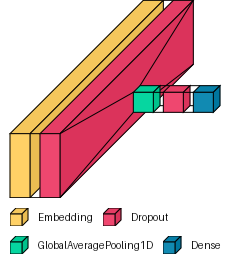

In [92]:
# Render the model with Visualkeras into a file
import visualkeras 

visualkeras.layered_view(model, legend=True, to_file='model.png')

## Training the model

Finally we run and train the model.

In [93]:
#hide_output
# Train the model
history = model.fit(training_sentences, training_sentiments,
                    batch_size=batch_size,
                    epochs=60,
                    validation_data=(validation_sentences, validation_sentiments),
                    verbose=1, # Set to 1 to print the training log
                    callbacks=[tensorboard_callback,early_stopping_callback])

## Plotting and visualizing the training history

At this stage, we can visualize the progression of our model's training through the lenses of accuracy and loss metrics. These two indicators provide essential insights into how well our model is performing and learning over time.

**Accuracy** is a measure of how often the model's predictions match the true labels of the data. It's a direct indicator of the model's performance, with higher values indicating better performance. In the context of training and validation, we typically observe two accuracy trends: one for the training set (showing how well the model fits the data it learns from) and one for the validation set (indicating how well the model generalizes to new, unseen data). An ideal model demonstrates high accuracy on both training and validation sets, suggesting it has learned well and can generalize its learning effectively.

**Loss**, on the other hand, quantifies the difference between the model's predicted values and the actual values for a given number of instances. It is a critical measure used during the training process to adjust the model's weights with the objective of minimizing this difference, hence improving the model's predictions. Like accuracy, we monitor loss for both training and validation datasets. A decreasing trend in loss over epochs signifies that the model is learning correctly. However, if validation loss starts to increase while training loss continues to decrease, it could indicate overfitting—meaning the model is performing well on the training data but poorly on new, unseen data.

Visualizing accuracy and loss during training provides valuable feedback on the learning process. It helps identify when the model has started to overfit, underfit, or if it's learning as expected. These insights guide adjustments to the model architecture, the training process, or even to the data itself, with the goal of achieving a well-performing model that generalizes well to new data.

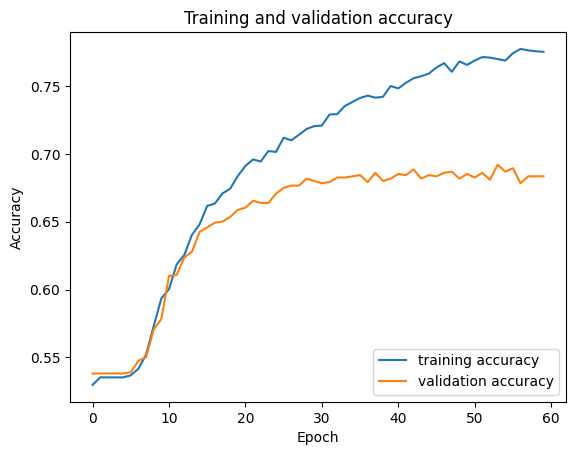

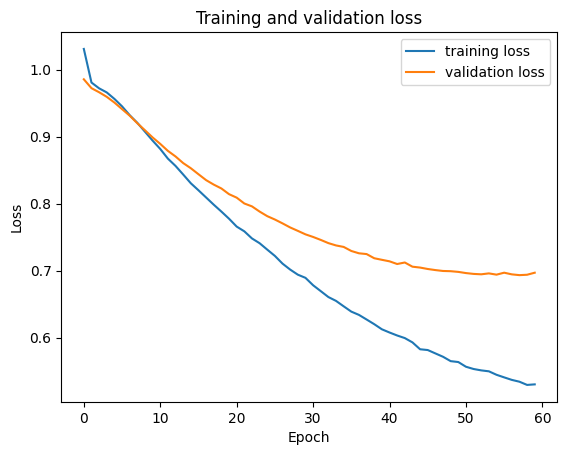

In [94]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='training accuracy')
plt.plot(history.history['val_accuracy'], label = 'validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label = 'validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

## Final remarks

In this exercise, we have undertaken the task of constructing a basic neural network using TensorFlow and Keras. The process covered essential steps including data preparation, loading, and network training. Despite the educational value of this exercise, we encountered limitations due to the small size of our dataset, which led to observable overfitting and modest accuracy levels.

These challenges emphasize the critical balance between model complexity and the scope and quality of data. Small datasets may not provide the model with sufficient information to learn generalized patterns effectively, resulting in superior performance on training data but poor generalizability to new, unseen data.

This experiment, while highlighting certain limitations, also sets the stage for future exploration. It brings to light the importance of employing strategies to mitigate overfitting, such as incorporating dropout layers, applying regularization techniques, or enhancing the dataset through augmentation. Furthermore, it invites the exploration of more advanced models, hyperparameter optimization, and the acquisition of larger and more varied datasets to improve model performance.